# Exploratory Data Analysis: Frog Species Calls, Temperature & Humidity

**Dataset:** `df_helechos_with2020.csv` — hourly recordings of two frog species (*Gastrotheca chysosticta* and *Oreobates berdemenos*) call intensities (ordinal 0–3), temperature (°C), and relative humidity (%).

**Coverage:** ~Sep 2018 – Jul 2020 (with a gap from early 2020 to mid-2020). Humidity data is only available until ~Jan 2020.

---

## 0. Setup & Configuration

In [6]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Display options ─────────────────────────────────────────────────────────
np.set_printoptions(linewidth=150)
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": True,
})

# ── Colour palette (consistent across notebook) ────────────────────────────
COLORS = {
    "gastro": "#1f77b4",      # blue
    "oreo": "#ff7f0e",        # orange
    "both": "#2ca02c",        # green
    "temp": "#d62728",        # red
    "rh": "#9467bd",          # purple
}

SPECIES = ["Gastrotheca chysosticta", "Oreobates berdemenos"]
SP_SHORT = {"Gastrotheca chysosticta": "G. chysosticta",
            "Oreobates berdemenos": "O. berdemenos"}
SP_COLOR = {"Gastrotheca chysosticta": COLORS["gastro"],
            "Oreobates berdemenos": COLORS["oreo"]}

# ── Output folder for saved plots ──────────────────────────────────────────
PLOT_DIR = Path("plots_eda")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name, formats=("pdf", "svg")):
    """Save figure in requested formats with tight bbox."""
    for fmt in formats:
        fig.savefig(PLOT_DIR / f"{name}.{fmt}", bbox_inches="tight")
    print(f"  ✓ Saved: {name}.pdf / .svg")

print("Setup complete. Plots will be saved to:", PLOT_DIR.resolve())

Setup complete. Plots will be saved to: /Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Coding/yungas_aruna/Gastros_helechos/Granger_causality/plots_eda


## 1. Load Data & Initial Inspection

In [7]:
# ── Load the dataset ─────────────────────────────────────────────────────────
PT_drive = "/Users/ash/Library/CloudStorage/OneDrive-Nexus365/PHD/arunan/Martin_google_drive"

df = pd.read_csv(f"{PT_drive}/df_helechos_with2020.csv")
df["DateTime"] = pd.to_datetime(df["DateTime"], errors="coerce")
df = df.set_index("DateTime").sort_index()

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Total hours: {len(df):,}")
df.head()

Shape: (13257, 8)
Date range: 2018-09-02 00:00:00 → 2020-07-18 23:00:00
Total hours: 13,257


,Date,Month,Day,hour,Temp,RH%,Gastrotheca chrysosticta,Oreobates berdemenos
DateTime,,,,,,,,
2018-09-02 00:00:00,2018-09-02,9,245,0,4.553,100.0,0,0
2018-09-02 01:00:00,2018-09-02,9,245,1,4.051,100.0,0,0
2018-09-02 02:00:00,2018-09-02,9,245,2,4.553,100.0,0,0
2018-09-02 03:00:00,2018-09-02,9,245,3,3.550,100.0,0,0
2018-09-02 04:00:00,2018-09-02,9,245,4,3.048,100.0,0,0


In [8]:
# ── Info & descriptive statistics ────────────────────────────────────────────
df.info()
print("\n")
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13257 entries, 2018-09-02 00:00:00 to 2020-07-18 23:00:00
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      13257 non-null  object 
 1   Month                     13257 non-null  int64  
 2   Day                       13257 non-null  int64  
 3   hour                      13257 non-null  int64  
 4   Temp                      13257 non-null  float64
 5   RH%                       11303 non-null  float64
 6   Gastrotheca chrysosticta  13257 non-null  int64  
 7   Oreobates berdemenos      13257 non-null  int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 932.1+ KB




,Month,Day,hour,Temp,RH%,Gastrotheca chrysosticta,Oreobates berdemenos
count,13257.000000,13257.000000,13257.000000,13257.000000,11303.000000,13257.000000,13257.000000
mean,7.339896,207.507807,11.504941,15.520983,89.388759,0.159161,0.101003
std,3.325262,101.813928,6.918789,5.033237,15.923785,0.563832,0.433209
min,1.000000,1.000000,0.000000,0.232000,15.000000,0.000000,0.000000
25%,5.000000,131.000000,6.000000,12.110000,83.535000,0.000000,0.000000
50%,7.000000,210.000000,12.000000,15.855000,98.140000,0.000000,0.000000
75%,10.000000,296.000000,17.000000,18.711000,100.000000,0.000000,0.000000
max,12.000000,365.000000,23.000000,37.274000,100.000000,3.000000,3.000000


Expected hourly timestamps: 16,464
Actual rows:                13,257
Missing hours (gap):        3,207
RH% non-null:               11,303 / 13,257
RH% last valid timestamp:   2019-12-16 23:00:00
  ✓ Saved: 01_data_coverage.pdf / .svg


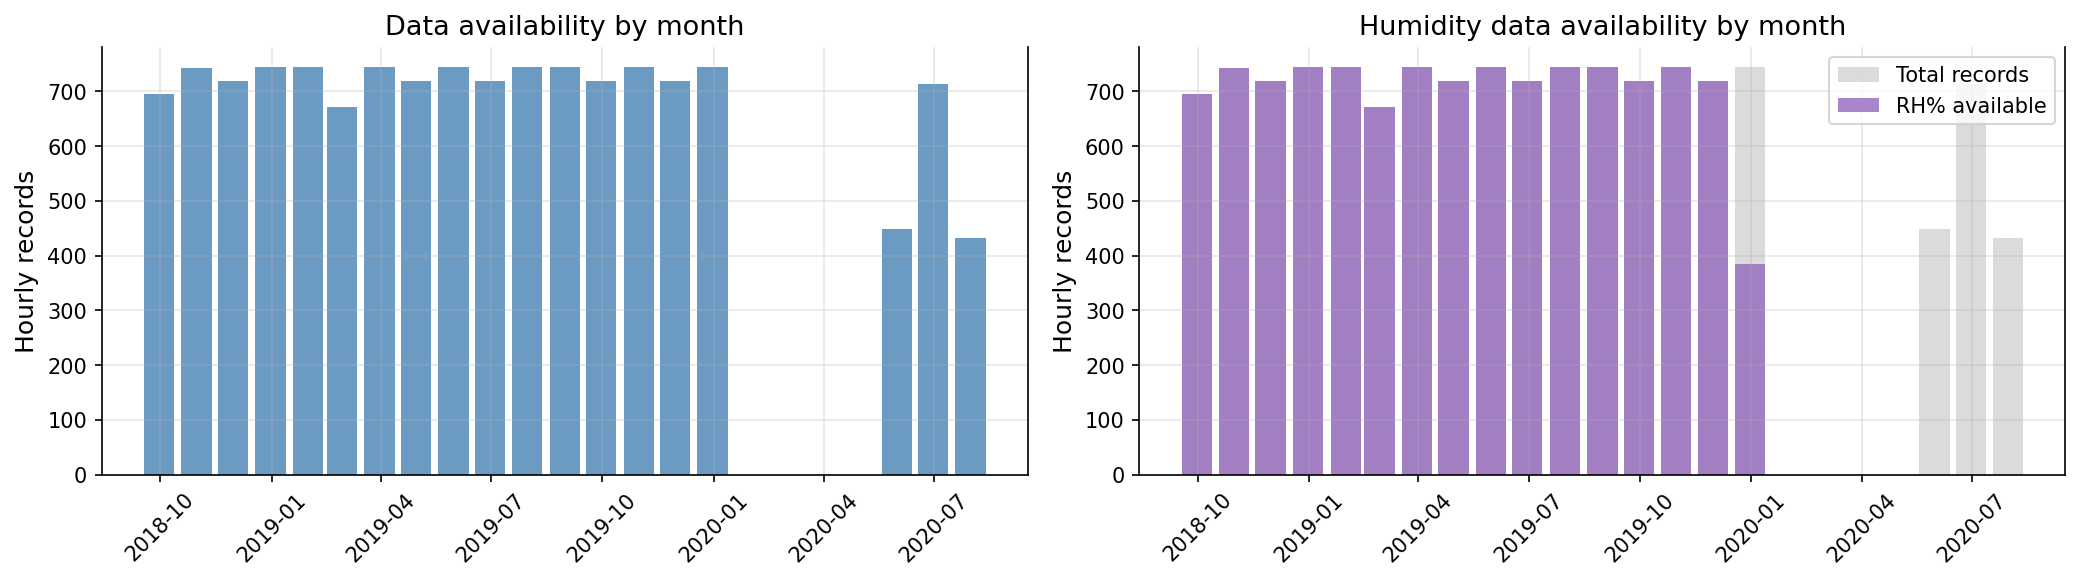

In [9]:
# ── Data coverage & missingness ──────────────────────────────────────────────
# Show where data exists vs. the expected continuous hourly range
full_range = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing_hours = full_range.difference(df.index)

print(f"Expected hourly timestamps: {len(full_range):,}")
print(f"Actual rows:                {len(df):,}")
print(f"Missing hours (gap):        {len(missing_hours):,}")
print(f"RH% non-null:               {df['RH%'].notna().sum():,} / {len(df):,}")
print(f"RH% last valid timestamp:   {df.loc[df['RH%'].notna()].index.max()}")

# Visual: data availability heatmap (by month)
fig_cov, axes_cov = plt.subplots(1, 2, figsize=(14, 4))

# Left: hourly record counts per month
monthly_counts = df.resample("ME").size()
axes_cov[0].bar(monthly_counts.index, monthly_counts.values, width=25, color="steelblue", alpha=0.8)
axes_cov[0].set_ylabel("Hourly records")
axes_cov[0].set_title("Data availability by month")
axes_cov[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes_cov[0].tick_params(axis="x", rotation=45)

# Right: RH% availability
rh_avail = df.resample("ME")["RH%"].apply(lambda x: x.notna().sum())
rh_total = df.resample("ME").size()
axes_cov[1].bar(rh_total.index, rh_total.values, width=25, color="lightgray", alpha=0.8, label="Total records")
axes_cov[1].bar(rh_avail.index, rh_avail.values, width=25, color=COLORS["rh"], alpha=0.8, label="RH% available")
axes_cov[1].set_ylabel("Hourly records")
axes_cov[1].set_title("Humidity data availability by month")
axes_cov[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes_cov[1].tick_params(axis="x", rotation=45)
axes_cov[1].legend()

fig_cov.tight_layout()
savefig(fig_cov, "01_data_coverage")
plt.show()

KeyError: 'Gastrotheca chysosticta'

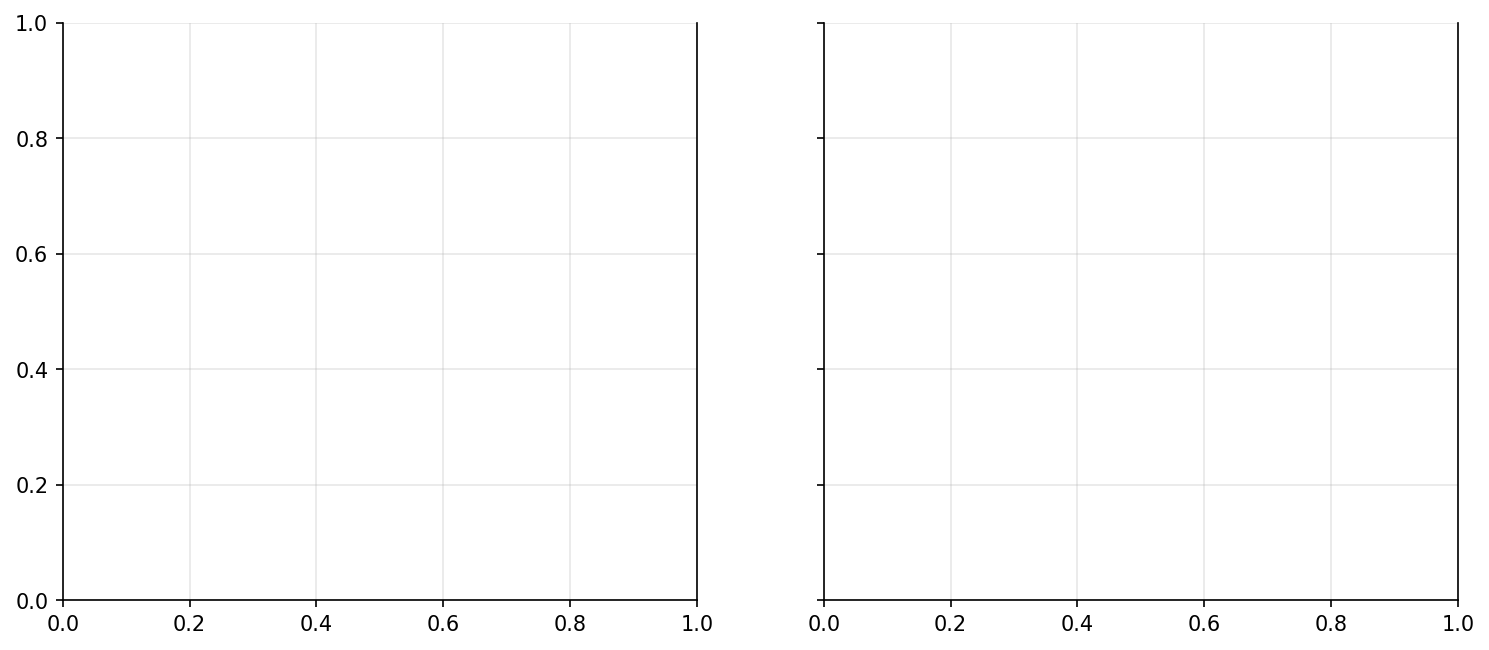

In [10]:
# ── Call-intensity distribution (bar charts) ────────────────────────────────
# Count how many hours each intensity level (0–3) occurs for each species
fig_dist, axes_dist = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, sp in zip(axes_dist, SPECIES):
    counts = df[sp].value_counts().sort_index()
    pcts = counts / counts.sum() * 100
    bars = ax.bar(counts.index, counts.values, color=SP_COLOR[sp], alpha=0.85, edgecolor="white")
    ax.set_xlabel("Call intensity level")
    ax.set_ylabel("Number of hours")
    ax.set_title(f"{SP_SHORT[sp]}")
    ax.set_xticks([0, 1, 2, 3])
    # Annotate percentage on each bar
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

fig_dist.suptitle("Distribution of Hourly Call Intensity Levels", fontsize=14)
fig_dist.tight_layout()
savefig(fig_dist, "02_call_intensity_distribution")
plt.show()

## 2. Full Time Series Overview

Raw hourly scatter of both species' call intensities overlaid with temperature and humidity. Green markers highlight hours where **both species** were calling simultaneously.

In [ ]:
# ── Raw hourly time series: species calls + temp + RH% ──────────────────────
fig_ts, ax1 = plt.subplots(figsize=(15, 7))

# Species calls on primary y-axis
ax1.scatter(df.index, df["Oreobates berdemenos"],
            color=COLORS["oreo"], label="O. berdemenos", s=18, alpha=0.7, zorder=10)
ax1.scatter(df.index, df["Gastrotheca chysosticta"],
            color=COLORS["gastro"], label="G. chysosticta", s=18, alpha=0.7, zorder=20)

# Hours where both species call
both = df[(df["Oreobates berdemenos"] > 0) & (df["Gastrotheca chysosticta"] > 0)]
if len(both) > 0:
    ax1.scatter(both.index, both["Oreobates berdemenos"],
                color=COLORS["both"], s=28, label="Both species", zorder=30)
    ax1.scatter(both.index, both["Gastrotheca chysosticta"],
                color=COLORS["both"], s=28, zorder=30)

ax1.set_xlabel("Date")
ax1.set_ylabel("Call intensity (0–3)")
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

# Temperature (secondary axis)
ax2 = ax1.twinx()
ax2.plot(df.index, df["Temp"], color=COLORS["temp"], linewidth=0.8, alpha=0.55, label="Temperature (°C)")
ax2.set_ylabel("Temperature (°C)", color=COLORS["temp"])
ax2.tick_params(axis="y", labelcolor=COLORS["temp"])

# Humidity (tertiary axis)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.10))
ax3.plot(df.index, df["RH%"], color=COLORS["rh"], linewidth=0.8, alpha=0.6, label="RH%")
ax3.set_ylabel("Relative Humidity (%)", color=COLORS["rh"])
ax3.tick_params(axis="y", labelcolor=COLORS["rh"])

# Bring call axis to front
for a in (ax1, ax2, ax3):
    a.set_facecolor("none")
    a.patch.set_alpha(0)
ax1.set_zorder(3); ax2.set_zorder(1); ax3.set_zorder(2)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax1.legend(h1 + h2 + h3, l1 + l2 + l3, loc="upper right", framealpha=0.9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig_ts.autofmt_xdate()
fig_ts.suptitle("Species Call Intensities and Weather Over Time (Hourly)", fontsize=14)
fig_ts.tight_layout()
savefig(fig_ts, "03_raw_timeseries_full")
plt.show()

In [ ]:
# ── Smoothed daily time series ───────────────────────────────────────────────
# Sum calls per day, mean weather per day, then apply 7-day rolling mean
daily_calls = df[SPECIES].resample("D").sum()
daily_weather = df[["Temp", "RH%"]].resample("D").mean()
daily_all = daily_calls.join(daily_weather)

SMOOTH_WIN = 7  # days
daily_smooth = daily_all.rolling(SMOOTH_WIN, center=True, min_periods=1).mean()

fig_sm, ax_sm = plt.subplots(figsize=(14, 6))

# Calls (primary)
for sp in SPECIES:
    ax_sm.plot(daily_smooth.index, daily_smooth[sp],
               label=f"{SP_SHORT[sp]} (daily sum, {SMOOTH_WIN}d rolling mean)",
               color=SP_COLOR[sp], linewidth=1.4)
ax_sm.set_xlabel("Date")
ax_sm.set_ylabel("Daily call total (smoothed)")

# Weather (secondary)
ax_sm2 = ax_sm.twinx()
ax_sm2.plot(daily_smooth.index, daily_smooth["Temp"],
            color=COLORS["temp"], linewidth=1.1, alpha=0.75,
            label=f"Temp (°C, {SMOOTH_WIN}d mean)")
ax_sm2.plot(daily_smooth.index, daily_smooth["RH%"],
            color=COLORS["rh"], linewidth=1.0, alpha=0.75,
            label=f"RH% ({SMOOTH_WIN}d mean)")
ax_sm2.set_ylabel("Temperature (°C) / Humidity (%)")

# Combined legend
h1, l1 = ax_sm.get_legend_handles_labels()
h2, l2 = ax_sm2.get_legend_handles_labels()
ax_sm2.legend(h1 + h2, l1 + l2, loc="upper right", ncol=2, framealpha=0.9)

fig_sm.suptitle(f"Smoothed Daily Time Series ({SMOOTH_WIN}-day Rolling Mean)", fontsize=14)
fig_sm.tight_layout()
savefig(fig_sm, "04_daily_smoothed_timeseries")
plt.show()

## 3. Hourly (Diurnal) Patterns

Aggregated across all days in the dataset. Each hour of the day (0–23) is summarised by its mean, standard deviation, and quantile ranges.

In [ ]:
# ── 3a. Mean call intensity per hour-of-day ─────────────────────────────────
# Average (mean) of each variable over all days, grouped by hour.
hourly_mean = df.groupby("hour")[SPECIES + ["Temp", "RH%"]].mean().reindex(range(24))

fig_hm, ax_hm = plt.subplots(figsize=(11, 5))

for sp in SPECIES:
    ax_hm.plot(hourly_mean.index, hourly_mean[sp],
               marker="o", ms=5, label=SP_SHORT[sp], color=SP_COLOR[sp], linewidth=1.5)
ax_hm.set_xlabel("Hour of day")
ax_hm.set_ylabel("Mean call intensity")
ax_hm.set_xticks(range(24))

# Weather on secondary axis
ax_hm2 = ax_hm.twinx()
ax_hm2.plot(hourly_mean.index, hourly_mean["Temp"],
            marker="s", ms=4, color=COLORS["temp"], linewidth=1.2, alpha=0.7, label="Temp (°C)")
ax_hm2.plot(hourly_mean.index, hourly_mean["RH%"],
            marker="^", ms=4, color=COLORS["rh"], linewidth=1.2, alpha=0.7, label="RH%")
ax_hm2.set_ylabel("Temperature (°C) / Humidity (%)")

h1, l1 = ax_hm.get_legend_handles_labels()
h2, l2 = ax_hm2.get_legend_handles_labels()
ax_hm.legend(h1 + h2, l1 + l2, loc="upper left", ncol=2, framealpha=0.9)

fig_hm.suptitle("Mean Hourly Profile (averaged across all days)", fontsize=14)
fig_hm.tight_layout()
savefig(fig_hm, "05_hourly_mean_profile")
plt.show()

In [ ]:
# ── 3b. Hourly profile with quantile ribbons (10–90% and 25–75%) ────────────
# Reorder hours to start at noon (12:00) so nocturnal activity is centred.
hour_order = list(range(12, 24)) + list(range(0, 12))
x_pos = np.arange(24)

hourly_stats = df.groupby("hour")[SPECIES].agg(["mean", "std"]).reindex(range(24))
hourly_quant = (
    df.groupby("hour")[SPECIES]
      .quantile([0.10, 0.25, 0.75, 0.90])
      .unstack()
      .reindex(range(24))
)

fig_hq, ax_hq = plt.subplots(figsize=(13, 6))

for sp in SPECIES:
    m   = hourly_stats[(sp, "mean")].reindex(hour_order).values
    q10 = hourly_quant[(sp, 0.10)].reindex(hour_order).values
    q25 = hourly_quant[(sp, 0.25)].reindex(hour_order).values
    q75 = hourly_quant[(sp, 0.75)].reindex(hour_order).values
    q90 = hourly_quant[(sp, 0.90)].reindex(hour_order).values
    c = SP_COLOR[sp]

    ax_hq.fill_between(x_pos, q10, q90, color=c, alpha=0.12, linewidth=0,
                        label=f"{SP_SHORT[sp]} 10–90%")
    ax_hq.fill_between(x_pos, q25, q75, color=c, alpha=0.28, linewidth=0,
                        label=f"{SP_SHORT[sp]} 25–75%")
    ax_hq.plot(x_pos, m, marker="o", ms=4, color=c, linewidth=1.4,
               label=f"{SP_SHORT[sp]} mean")

ax_hq.set_xlabel("Hour of day (starting 12:00)")
ax_hq.set_ylabel("Call intensity")
ax_hq.set_xticks(x_pos)
ax_hq.set_xticklabels(hour_order)

# De-duplicate legend
handles, labels = ax_hq.get_legend_handles_labels()
seen = {}
h_clean, l_clean = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True; h_clean.append(h); l_clean.append(l)
ax_hq.legend(h_clean, l_clean, ncol=2, loc="upper left", framealpha=0.9)

fig_hq.suptitle("Diurnal Call Profile — Mean with Quantile Ribbons (all days)", fontsize=14)
fig_hq.tight_layout()
savefig(fig_hq, "06_hourly_quantile_ribbons")
plt.show()

In [ ]:
# ── 3c. Hourly ±1σ ribbons with separate weather axes ───────────────────────
# Calls on primary axis, temperature on secondary (0–30 °C), RH% on tertiary (0–100%).
hourly_grp = df.groupby("hour")
mean_all = hourly_grp[SPECIES + ["Temp", "RH%"]].mean().reindex(range(24))
std_all  = hourly_grp[SPECIES + ["Temp", "RH%"]].std().reindex(range(24)).fillna(0)

fig_hs, ax_c = plt.subplots(figsize=(12, 6))

def ribbon(ax, x, m, s, label, color, floor_zero=False):
    lo = (m - s).clip(lower=0) if floor_zero else m - s
    hi = m + s
    ax.fill_between(x, lo, hi, color=color, alpha=0.18, linewidth=0)
    return ax.plot(x, m, marker="o", ms=4, color=color, label=label, linewidth=1.2)[0]

hrs = range(24)
l1 = ribbon(ax_c, hrs, mean_all["Oreobates berdemenos"], std_all["Oreobates berdemenos"],
            "O. berdemenos (mean ±1σ)", COLORS["oreo"], floor_zero=True)
l2 = ribbon(ax_c, hrs, mean_all["Gastrotheca chysosticta"], std_all["Gastrotheca chysosticta"],
            "G. chysosticta (mean ±1σ)", COLORS["gastro"], floor_zero=True)
ax_c.set_xlabel("Hour of day")
ax_c.set_ylabel("Call intensity")
ax_c.set_xticks(range(24))

# Temperature axis
ax_t = ax_c.twinx()
l3 = ax_t.plot(hrs, mean_all["Temp"], marker="s", ms=3, color=COLORS["temp"],
               linewidth=1.1, label="Temperature (°C)")[0]
ax_t.set_ylabel("Temperature (°C)", color=COLORS["temp"])
ax_t.tick_params(axis="y", labelcolor=COLORS["temp"])
ax_t.set_ylim(0, 30)

# RH% axis
ax_r = ax_c.twinx()
ax_r.spines["right"].set_position(("axes", 1.12))
l4 = ax_r.plot(hrs, mean_all["RH%"], marker="^", ms=3, color=COLORS["rh"],
               linewidth=1.1, label="RH%")[0]
ax_r.set_ylabel("Relative Humidity (%)", color=COLORS["rh"])
ax_r.tick_params(axis="y", labelcolor=COLORS["rh"])
ax_r.set_ylim(0, 100)

ax_c.set_zorder(10); ax_c.patch.set_alpha(0)
ax_c.legend([l1, l2, l3, l4], [l.get_label() for l in [l1, l2, l3, l4]],
            ncol=2, loc="upper left", framealpha=0.9)

fig_hs.suptitle("Hourly Calls (mean ±1σ) with Temperature & Humidity", fontsize=14)
fig_hs.tight_layout()
savefig(fig_hs, "07_hourly_std_ribbons_weather")
plt.show()

In [ ]:
# ── 3d. Asymmetric standard deviation per hour ──────────────────────────────
# Compute one-sided std above and below the mean separately per hour.
# This captures the skewed nature of ordinal call data.

grp = df.groupby("hour")
hour_mean = grp[SPECIES + ["Temp", "RH%"]].mean().reindex(range(24))
cols_plot = SPECIES + ["Temp", "RH%"]

std_up   = pd.DataFrame(index=range(24), columns=cols_plot, dtype=float)
std_down = pd.DataFrame(index=range(24), columns=cols_plot, dtype=float)

for h in range(24):
    sub = df[df["hour"] == h]
    for col in cols_plot:
        vals = sub[col].dropna()
        m = hour_mean.loc[h, col]
        above = vals[vals >= m]
        below = vals[vals <= m]
        std_up.loc[h, col]   = np.sqrt(((above - m) ** 2).mean()) if len(above) > 1 else 0.0
        std_down.loc[h, col] = np.sqrt(((below - m) ** 2).mean()) if len(below) > 1 else 0.0

# Scale weather for combined plot
scale = {"Temp": 20.0, "RH%": 100.0}
mean_sc = hour_mean.copy()
up_sc   = std_up.copy()
dn_sc   = std_down.copy()
for col, s in scale.items():
    mean_sc[col] /= s; up_sc[col] /= s; dn_sc[col] /= s

all_colors = {**SP_COLOR, "Temp": COLORS["temp"], "RH%": COLORS["rh"]}

fig_asym, ax_asym = plt.subplots(figsize=(12, 5.5))
for col in cols_plot:
    m = mean_sc[col]
    upper = m + up_sc[col]
    lower = m - dn_sc[col]
    ax_asym.plot(range(24), m, marker="o", ms=4, color=all_colors[col], linewidth=1.2,
                 label=f"{col} mean")
    ax_asym.fill_between(range(24), lower, upper, color=all_colors[col], alpha=0.18, linewidth=0,
                         label=f"{col} ± asym σ")

ax_asym.set_xlabel("Hour of day")
ax_asym.set_ylabel("Call intensity / Scaled weather\n(Temp÷20, RH%÷100)")
ax_asym.set_xticks(range(24))

# De-duplicate legend
handles, labels = ax_asym.get_legend_handles_labels()
seen = set(); hc, lc = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l); hc.append(h); lc.append(l)
ax_asym.legend(hc, lc, ncol=2, fontsize=9, framealpha=0.9)

fig_asym.suptitle("Hourly Mean with Asymmetric Standard Deviation", fontsize=14)
fig_asym.tight_layout()
savefig(fig_asym, "08_hourly_asymmetric_std")
plt.show()

In [ ]:
# ── 3e. Proportion of hours with calls > 0, by hour of day ──────────────────
# Shows the probability of hearing each species at each hour.
hourly_presence = df.groupby("hour")[SPECIES].apply(lambda x: (x > 0).mean()).reindex(range(24))

fig_pres, ax_pres = plt.subplots(figsize=(11, 5))
for sp in SPECIES:
    ax_pres.bar(hourly_presence.index + (0.2 if sp == SPECIES[1] else -0.2),
                hourly_presence[sp], width=0.38,
                color=SP_COLOR[sp], alpha=0.85, label=SP_SHORT[sp])
ax_pres.set_xlabel("Hour of day")
ax_pres.set_ylabel("Proportion of hours with calls > 0")
ax_pres.set_xticks(range(24))
ax_pres.legend(framealpha=0.9)
ax_pres.set_ylim(0, min(1.0, hourly_presence.max().max() * 1.3))

fig_pres.suptitle("Calling Probability by Hour of Day", fontsize=14)
fig_pres.tight_layout()
savefig(fig_pres, "09_hourly_calling_probability")
plt.show()

## 4. Day-of-Year (Seasonal) Patterns

Daily call totals (sum of 24 hours) and daily mean weather, averaged across the ~1.5 years to produce a single annual cycle profile.

In [ ]:
# ── 4a. Average day-of-year profile: calls & weather ────────────────────────
# Daily totals for calls, daily mean for weather, then average by day-of-year
daily_calls["doy"] = daily_calls.index.dayofyear
daily_weather["doy"] = daily_weather.index.dayofyear

doy_mean_calls   = daily_calls.groupby("doy")[SPECIES].mean().reindex(range(1, 366))
doy_mean_weather = daily_weather.groupby("doy")[["Temp", "RH%"]].mean().reindex(range(1, 366))

fig_doy, ax_doy = plt.subplots(figsize=(13, 5.5))
for sp in SPECIES:
    ax_doy.plot(doy_mean_calls.index, doy_mean_calls[sp],
                marker=".", ms=3, linewidth=1, label=SP_SHORT[sp], color=SP_COLOR[sp])
ax_doy.set_xlabel("Day of year")
ax_doy.set_ylabel("Mean daily call total (sum over hours, avg across years)")

ax_doy2 = ax_doy.twinx()
ax_doy2.plot(doy_mean_weather.index, doy_mean_weather["Temp"],
             color=COLORS["temp"], linewidth=1.1, label="Temp (°C)")
ax_doy2.plot(doy_mean_weather.index, doy_mean_weather["RH%"],
             color=COLORS["rh"], linewidth=1.0, alpha=0.8, label="RH%")
ax_doy2.set_ylabel("Temperature (°C) / Humidity (%)")

h1, l1 = ax_doy.get_legend_handles_labels()
h2, l2 = ax_doy2.get_legend_handles_labels()
ax_doy2.legend(h1 + h2, l1 + l2, loc="upper right", ncol=2, framealpha=0.9)

fig_doy.suptitle("Day-of-Year Average: Daily Call Totals and Weather", fontsize=14)
fig_doy.tight_layout()
savefig(fig_doy, "10_doy_average_calls_weather")
plt.show()

In [ ]:
# ── 4b. Day-of-year with min–max ribbons (5-day pre-smoothed) ───────────────
# First smooth each day's totals with a 5-day rolling window, THEN group by DOY.
# This reduces day-to-day noise while preserving the inter-year spread.

SMOOTH_W = 5
daily_calls_sm = daily_calls[SPECIES].rolling(SMOOTH_W, center=True, min_periods=1).mean()
daily_calls_sm["doy"] = daily_calls["doy"]
daily_weather_sm = daily_weather[["Temp", "RH%"]].rolling(SMOOTH_W, center=True, min_periods=1).mean()
daily_weather_sm["doy"] = daily_weather["doy"]

doy_call_stats = daily_calls_sm.groupby("doy")[SPECIES].agg(["mean", "min", "max"]).reindex(range(1, 366))
doy_wx_stats   = daily_weather_sm.groupby("doy")[["Temp", "RH%"]].agg(["mean", "min", "max"]).reindex(range(1, 366))

fig_dr, ax_left = plt.subplots(figsize=(13, 5.5))
ax_right = ax_left.twinx()

for sp in SPECIES:
    m  = doy_call_stats[(sp, "mean")]
    mn = doy_call_stats[(sp, "min")]
    mx = doy_call_stats[(sp, "max")]
    c = SP_COLOR[sp]
    ax_left.fill_between(m.index, mn, mx, color=c, alpha=0.15, linewidth=0)
    ax_left.plot(m.index, m, color=c, linewidth=1.2, label=f"{SP_SHORT[sp]} mean (min–max)")

for env, c in [("Temp", COLORS["temp"]), ("RH%", COLORS["rh"])]:
    m  = doy_wx_stats[(env, "mean")]
    mn = doy_wx_stats[(env, "min")]
    mx = doy_wx_stats[(env, "max")]
    ax_right.fill_between(m.index, mn, mx, color=c, alpha=0.12, linewidth=0)
    ax_right.plot(m.index, m, color=c, linewidth=1.1, label=f"{env} mean (min–max)")

ax_left.set_xlabel("Day of year")
ax_left.set_ylabel("Daily calls (sum)")
ax_right.set_ylabel("Weather (°C / RH%)")

h1, l1 = ax_left.get_legend_handles_labels()
h2, l2 = ax_right.get_legend_handles_labels()
ax_right.legend(h1 + h2, l1 + l2, loc="upper right", ncol=2, framealpha=0.9)

fig_dr.suptitle(f"Day-of-Year: Mean with Min–Max Ribbons ({SMOOTH_W}-day pre-smoothed)", fontsize=14)
fig_dr.tight_layout()
savefig(fig_dr, "11_doy_minmax_ribbons")
plt.show()

In [ ]:
# ── 4c. Day-of-year subplots (individual panels per variable) ───────────────
# Four panels: one per variable, each showing mean ± min/max error bars.
vars_panel = SPECIES + ["Temp", "RH%"]
panel_colors = {**SP_COLOR, "Temp": COLORS["temp"], "RH%": COLORS["rh"]}

# Use 7-day smoothed daily data averaged by DOY
daily_all_sm = daily_all.rolling(7, center=True, min_periods=1).mean()
daily_all_sm["doy"] = daily_all_sm.index.dayofyear
doy_panel = daily_all_sm.groupby("doy")[vars_panel].agg(["mean", "min", "max"])

fig_pan, axes_pan = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes_pan = axes_pan.ravel()

for ax, var in zip(axes_pan, vars_panel):
    m  = doy_panel[(var, "mean")]
    lo = m - doy_panel[(var, "min")]
    hi = doy_panel[(var, "max")] - m
    ax.errorbar(m.index, m, yerr=np.vstack([lo, hi]),
                fmt="-", markersize=0, linewidth=1, elinewidth=0.5,
                ecolor=panel_colors[var], color=panel_colors[var], alpha=0.85, capsize=0)
    ax.set_title(var, fontsize=12)
    short = SP_SHORT.get(var, var)
    ax.legend([f"{short} mean (min–max)"], fontsize=9, framealpha=0.9)

axes_pan[2].set_xlabel("Day of year")
axes_pan[3].set_xlabel("Day of year")
axes_pan[0].set_ylabel("Daily calls")
axes_pan[2].set_ylabel("Value")

fig_pan.suptitle("Day-of-Year Profiles (7-day smoothed, mean with min–max)", fontsize=14)
fig_pan.tight_layout()
savefig(fig_pan, "12_doy_subplots")
plt.show()

## 5. Monthly Aggregations

Monthly summaries using box-plots, bar charts, and heatmaps. The "Month" column already exists in the data (1–12).

In [ ]:
# ── 5a. Monthly boxplots of hourly call intensity ───────────────────────────
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig_box, axes_box = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)

for ax, sp in zip(axes_box, SPECIES):
    data_box = [df.loc[df["Month"] == m, sp].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(data_box, patch_artist=True, showfliers=True,
                    flierprops=dict(marker=".", ms=3, alpha=0.4),
                    medianprops=dict(color="black", linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(SP_COLOR[sp])
        patch.set_alpha(0.55)
    ax.set_xticklabels(month_names, rotation=45, ha="right")
    ax.set_xlabel("Month")
    ax.set_title(SP_SHORT[sp])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

axes_box[0].set_ylabel("Hourly call intensity (0–3)")
fig_box.suptitle("Monthly Distribution of Hourly Call Intensities", fontsize=14)
fig_box.tight_layout()
savefig(fig_box, "13_monthly_boxplots")
plt.show()

In [ ]:
# ── 5b. Monthly mean daily totals (bar chart) ───────────────────────────────
# Sum calls per day, then average across days within each month.
monthly_daily_mean = daily_calls.groupby(daily_calls.index.month)[SPECIES].mean()

fig_mb, ax_mb = plt.subplots(figsize=(11, 5))
bar_w = 0.35
months = np.arange(1, 13)
for i, sp in enumerate(SPECIES):
    ax_mb.bar(months + (i - 0.5) * bar_w, monthly_daily_mean[sp],
              width=bar_w, color=SP_COLOR[sp], alpha=0.85, label=SP_SHORT[sp])
ax_mb.set_xlabel("Month")
ax_mb.set_ylabel("Mean daily call total (sum over hours)")
ax_mb.set_xticks(months)
ax_mb.set_xticklabels(month_names, rotation=45, ha="right")
ax_mb.legend(framealpha=0.9)

fig_mb.suptitle("Average Daily Call Totals by Month", fontsize=14)
fig_mb.tight_layout()
savefig(fig_mb, "14_monthly_mean_daily_calls")
plt.show()

In [ ]:
# ── 5c. Heatmap: Month × Hour mean call intensity ───────────────────────────
# Average call intensity for each (month, hour) cell across all data.

fig_hm2, axes_hm2 = plt.subplots(1, 2, figsize=(16, 5.5))

for ax, sp in zip(axes_hm2, SPECIES):
    pivot = df.pivot_table(values=sp, index="Month", columns="hour", aggfunc="mean")
    pivot = pivot.reindex(index=range(1, 13), columns=range(24), fill_value=0)
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", origin="lower",
                   interpolation="nearest")
    ax.set_yticks(range(12))
    ax.set_yticklabels(month_names)
    ax.set_xticks(range(24))
    ax.set_xticklabels(range(24), fontsize=8)
    ax.set_xlabel("Hour of day")
    ax.set_title(SP_SHORT[sp])
    plt.colorbar(im, ax=ax, label="Mean intensity", shrink=0.8)

axes_hm2[0].set_ylabel("Month")
fig_hm2.suptitle("Mean Call Intensity by Month × Hour", fontsize=14)
fig_hm2.tight_layout()
savefig(fig_hm2, "15_heatmap_month_hour")
plt.show()

In [ ]:
# ── 5d. Monthly weather boxplots ─────────────────────────────────────────────
fig_wbox, axes_wbox = plt.subplots(1, 2, figsize=(15, 5))

for ax, (var, c) in zip(axes_wbox, [("Temp", COLORS["temp"]), ("RH%", COLORS["rh"])]):
    data_box = [df.loc[df["Month"] == m, var].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(data_box, patch_artist=True, showfliers=True,
                    flierprops=dict(marker=".", ms=3, alpha=0.3),
                    medianprops=dict(color="black", linewidth=1.5))
    for patch in bp["boxes"]:
        patch.set_facecolor(c)
        patch.set_alpha(0.5)
    ax.set_xticklabels(month_names, rotation=45, ha="right")
    ax.set_xlabel("Month")
    ax.set_title(var)
    unit = "°C" if var == "Temp" else "%"
    ax.set_ylabel(f"{var} ({unit})")

fig_wbox.suptitle("Monthly Weather Distributions", fontsize=14)
fig_wbox.tight_layout()
savefig(fig_wbox, "16_monthly_weather_boxplots")
plt.show()

## 6. Correlations & Co-occurrence

Pairwise scatter matrix with Pearson correlations, and species co-occurrence analysis.

In [ ]:
# ── 6a. Pairwise scatter matrix with Pearson r ─────────────────────────────
scatter_cols = ["Temp", "RH%"] + SPECIES
data_scatter = df[scatter_cols].dropna()
corr_mat = data_scatter.corr()
n_vars = len(scatter_cols)

fig_sc, axes_sc = plt.subplots(n_vars, n_vars, figsize=(3.3 * n_vars, 3.3 * n_vars))

for i, ycol in enumerate(scatter_cols):
    for j, xcol in enumerate(scatter_cols):
        ax = axes_sc[i, j]
        if i == j:
            ax.hist(data_scatter[xcol], bins=20, color="steelblue", alpha=0.8, edgecolor="white")
            ax.set_title(xcol, fontsize=10)
        else:
            ax.scatter(data_scatter[xcol], data_scatter[ycol],
                       s=12, alpha=0.4, edgecolors="none", color="tab:blue")
            # Least-squares line
            if data_scatter[xcol].nunique() > 1 and data_scatter[ycol].nunique() > 1:
                m, b = np.polyfit(data_scatter[xcol], data_scatter[ycol], 1)
                xs = np.linspace(data_scatter[xcol].min(), data_scatter[xcol].max(), 50)
                ax.plot(xs, m * xs + b, color="orange", linewidth=1)
            r = corr_mat.loc[ycol, xcol]
            ax.text(0.04, 0.92, f"r = {r:.2f}", transform=ax.transAxes,
                    fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.7, lw=0.5))
        ax.tick_params(axis="both", labelsize=8)
        if i == n_vars - 1:
            ax.set_xlabel(xcol, fontsize=9)
        if j == 0:
            ax.set_ylabel(ycol, fontsize=9)

fig_sc.suptitle("Pairwise Scatter Matrix with Pearson Correlations", fontsize=15)
fig_sc.tight_layout(rect=(0, 0, 1, 0.97))
savefig(fig_sc, "17_scatter_matrix")
plt.show()

In [ ]:
# ── 6b. Species co-occurrence analysis ──────────────────────────────────────
# How often are both species calling in the same hour?

gastro_active = df["Gastrotheca chysosticta"] > 0
oreo_active   = df["Oreobates berdemenos"] > 0

n_total = len(df)
n_gastro = gastro_active.sum()
n_oreo   = oreo_active.sum()
n_both   = (gastro_active & oreo_active).sum()
n_either = (gastro_active | oreo_active).sum()
n_neither = n_total - n_either

print("=== Co-occurrence Summary (hourly) ===")
print(f"  Total hours:          {n_total:,}")
print(f"  G. chysosticta only:  {n_gastro - n_both:,}  ({(n_gastro - n_both) / n_total * 100:.1f}%)")
print(f"  O. berdemenos only:   {n_oreo - n_both:,}  ({(n_oreo - n_both) / n_total * 100:.1f}%)")
print(f"  Both calling:         {n_both:,}  ({n_both / n_total * 100:.1f}%)")
print(f"  Neither calling:      {n_neither:,}  ({n_neither / n_total * 100:.1f}%)")

# Contingency heatmap
contingency = pd.crosstab(df["Gastrotheca chysosticta"], df["Oreobates berdemenos"],
                           margins=True, margins_name="Total")
print("\nContingency table (G. chysosticta rows × O. berdemenos columns):")
display(contingency)

# Visualise as heatmap (without margins)
cont_core = contingency.iloc[:-1, :-1].astype(float)
fig_ct, ax_ct = plt.subplots(figsize=(6, 5))
im = ax_ct.imshow(cont_core.values, cmap="Blues", aspect="auto", origin="lower")
ax_ct.set_xticks(range(4)); ax_ct.set_xticklabels(range(4))
ax_ct.set_yticks(range(4)); ax_ct.set_yticklabels(range(4))
ax_ct.set_xlabel("O. berdemenos intensity")
ax_ct.set_ylabel("G. chysosticta intensity")
# Annotate counts
for i in range(4):
    for j in range(4):
        v = int(cont_core.iloc[i, j])
        ax_ct.text(j, i, f"{v}", ha="center", va="center",
                   color="white" if v > cont_core.values.max() * 0.6 else "black", fontsize=10)
plt.colorbar(im, ax=ax_ct, label="Hourly count", shrink=0.8)
fig_ct.suptitle("Co-occurrence: Intensity Level Contingency Table", fontsize=13)
fig_ct.tight_layout()
savefig(fig_ct, "18_cooccurrence_contingency")
plt.show()

## 7. Autocorrelation & Cross-correlation

Autocorrelation function (ACF) and partial autocorrelation function (PACF) of hourly call data, plus cross-correlation between the two species.

In [ ]:
# ── 7a. ACF and PACF for each species ───────────────────────────────────────
from statsmodels.tsa.stattools import acf, pacf

MAX_LAGS = 72  # 3 days of hourly lags

fig_acf, axes_acf = plt.subplots(2, 2, figsize=(15, 8))

for row, sp in enumerate(SPECIES):
    series = df[sp].dropna().values
    acf_vals = acf(series, nlags=MAX_LAGS, fft=True)
    pacf_vals = pacf(series, nlags=min(MAX_LAGS, len(series) // 2 - 1))

    # ACF
    ax = axes_acf[row, 0]
    ax.bar(range(len(acf_vals)), acf_vals, width=0.6, color=SP_COLOR[sp], alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(1.96 / np.sqrt(len(series)), linestyle="--", color="gray", linewidth=0.8)
    ax.axhline(-1.96 / np.sqrt(len(series)), linestyle="--", color="gray", linewidth=0.8)
    ax.set_title(f"ACF — {SP_SHORT[sp]}")
    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("Autocorrelation")
    # Mark 24h multiples
    for mult in range(24, MAX_LAGS + 1, 24):
        ax.axvline(mult, color="lightcoral", linewidth=0.6, alpha=0.5, linestyle=":")

    # PACF
    ax = axes_acf[row, 1]
    ax.bar(range(len(pacf_vals)), pacf_vals, width=0.6, color=SP_COLOR[sp], alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axhline(1.96 / np.sqrt(len(series)), linestyle="--", color="gray", linewidth=0.8)
    ax.axhline(-1.96 / np.sqrt(len(series)), linestyle="--", color="gray", linewidth=0.8)
    ax.set_title(f"PACF — {SP_SHORT[sp]}")
    ax.set_xlabel("Lag (hours)")
    ax.set_ylabel("Partial autocorrelation")
    for mult in range(24, MAX_LAGS + 1, 24):
        ax.axvline(mult, color="lightcoral", linewidth=0.6, alpha=0.5, linestyle=":")

fig_acf.suptitle("Autocorrelation & Partial Autocorrelation (hourly, up to 72h)\n"
                  "Red dashed lines: 24h multiples", fontsize=13)
fig_acf.tight_layout()
savefig(fig_acf, "19_acf_pacf")
plt.show()

In [ ]:
# ── 7b. Cross-correlation between the two species ───────────────────────────
# ccf[k] = corr(Gastro[t], Oreo[t+k]). Positive lag → Oreo leads Gastro.
from scipy.signal import correlate

g = df["Gastrotheca chysosticta"].fillna(0).values.astype(float)
o = df["Oreobates berdemenos"].fillna(0).values.astype(float)
g = (g - g.mean()) / (g.std() + 1e-12)
o = (o - o.mean()) / (o.std() + 1e-12)

ccf_full = correlate(g, o, mode="full") / len(g)
lags_full = np.arange(-len(g) + 1, len(g))

# Restrict to ±72 hours
mask_ccf = (lags_full >= -72) & (lags_full <= 72)
lags_plot = lags_full[mask_ccf]
ccf_plot  = ccf_full[mask_ccf]

fig_ccf, ax_ccf = plt.subplots(figsize=(12, 4.5))
ax_ccf.bar(lags_plot, ccf_plot, width=0.8, color="teal", alpha=0.7)
ax_ccf.axhline(0, color="black", linewidth=0.5)
ax_ccf.axhline(1.96 / np.sqrt(len(g)), linestyle="--", color="gray", linewidth=0.8, label="95% CI")
ax_ccf.axhline(-1.96 / np.sqrt(len(g)), linestyle="--", color="gray", linewidth=0.8)
for mult in range(-72, 73, 24):
    if mult != 0:
        ax_ccf.axvline(mult, color="lightcoral", linewidth=0.6, alpha=0.5, linestyle=":")
ax_ccf.axvline(0, color="black", linewidth=0.8, alpha=0.5)
ax_ccf.set_xlabel("Lag (hours) — positive = O. berdemenos leads")
ax_ccf.set_ylabel("Cross-correlation")
ax_ccf.legend(loc="upper right")

fig_ccf.suptitle("Cross-Correlation: G. chysosticta vs O. berdemenos (±72h)", fontsize=13)
fig_ccf.tight_layout()
savefig(fig_ccf, "20_cross_correlation")
plt.show()

## 8. Detrending & Seasonality Removal

The raw call data is **highly seasonal** (strong diurnal + annual cycles). Below we apply several detrending methods and compare their residuals. Each method is described in detail.

### Methods compared:
1. **Differencing** — simple lag-24 differencing to remove the diurnal cycle
2. **Moving-average subtraction** — subtract a 24h (or 168h) centred rolling mean
3. **Fourier seasonal regression (OLS)** — fit sin/cos harmonics for hour-of-day and day-of-year, subtract fitted values
4. **Poisson GLM seasonal regression** — same Fourier features but with a Poisson link (appropriate for count data), subtract predicted mean
5. **STL decomposition** — Seasonal-Trend decomposition using LOESS (on daily totals)

In [ ]:
# ── 8a. Method 1: Lag-24 differencing ────────────────────────────────────────
# Subtract the value from 24 hours ago: y_diff[t] = y[t] - y[t-24]
# This removes the mean diurnal cycle (same hour yesterday).

diff_24 = {}
for sp in SPECIES:
    diff_24[sp] = df[sp] - df[sp].shift(24)

fig_d1, axes_d1 = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, sp in zip(axes_d1, SPECIES):
    vals = diff_24[sp].dropna()
    ax.plot(vals.index, vals, linewidth=0.4, alpha=0.6, color=SP_COLOR[sp])
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel(f"{SP_SHORT[sp]}\nΔ24h")

axes_d1[0].set_title("Detrended by Lag-24 Differencing (y[t] − y[t−24])")
axes_d1[-1].set_xlabel("Date")
fig_d1.tight_layout()
savefig(fig_d1, "21_detrend_lag24_diff")
plt.show()

In [ ]:
# ── 8b. Method 2: Moving-average subtraction (24h and 168h windows) ─────────
# Subtract a centred rolling mean. 24h removes the diurnal cycle;
# 168h (1 week) removes both diurnal and weekly patterns.

fig_ma, axes_ma = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for col_i, win in enumerate([24, 168]):
    for row_i, sp in enumerate(SPECIES):
        rolling_mean = df[sp].rolling(win, center=True, min_periods=1).mean()
        resid = df[sp] - rolling_mean
        ax = axes_ma[row_i, col_i]
        ax.plot(resid.index, resid, linewidth=0.4, alpha=0.6, color=SP_COLOR[sp])
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_ylabel(f"{SP_SHORT[sp]}")
        if row_i == 0:
            ax.set_title(f"Residual after {win}h centred rolling mean subtraction")

axes_ma[-1, 0].set_xlabel("Date")
axes_ma[-1, 1].set_xlabel("Date")
fig_ma.suptitle("Detrended by Moving-Average Subtraction", fontsize=14, y=1.01)
fig_ma.tight_layout()
savefig(fig_ma, "22_detrend_moving_average")
plt.show()

In [ ]:
# ── 8c. Method 3: Fourier seasonal regression (OLS) ─────────────────────────
# Fit: y = β₀ + Σ [aₖ sin(2πk·h/24) + bₖ cos(2πk·h/24)]   (k=1,2 harmonics for hour)
#            + Σ [cₖ sin(2πk·d/365) + dₖ cos(2πk·d/365)]   (k=1,2 harmonics for DOY)
# Then residual = y - ŷ
import statsmodels.api as sm

def fourier_ols_detrend(series, hour, doy, n_harmonics_hour=2, n_harmonics_doy=2):
    """OLS regression on Fourier basis, returns (fitted, residual)."""
    features = {}
    for k in range(1, n_harmonics_hour + 1):
        features[f"sin_h{k}"] = np.sin(2 * np.pi * k * hour / 24.0)
        features[f"cos_h{k}"] = np.cos(2 * np.pi * k * hour / 24.0)
    for k in range(1, n_harmonics_doy + 1):
        features[f"sin_d{k}"] = np.sin(2 * np.pi * k * doy / 365.0)
        features[f"cos_d{k}"] = np.cos(2 * np.pi * k * doy / 365.0)
    X = sm.add_constant(pd.DataFrame(features, index=series.index))
    model = sm.OLS(series, X).fit()
    return model.fittedvalues, model.resid

ols_fits = {}
ols_resids = {}
for sp in SPECIES:
    fitted, resid = fourier_ols_detrend(df[sp], df["hour"], df["Day"])
    ols_fits[sp] = fitted
    ols_resids[sp] = resid

# Plot: original + fitted on top; residual below
fig_ols, axes_ols = plt.subplots(2, 2, figsize=(15, 9))

for col_i, sp in enumerate(SPECIES):
    # Top: original + fitted
    ax_top = axes_ols[0, col_i]
    ax_top.scatter(df.index, df[sp], s=3, alpha=0.3, color=SP_COLOR[sp], label="Observed")
    ax_top.plot(ols_fits[sp].index, ols_fits[sp], color="black", linewidth=0.8, alpha=0.8,
                label="OLS Fourier fit")
    ax_top.set_ylabel("Call intensity")
    ax_top.set_title(f"{SP_SHORT[sp]}")
    ax_top.legend(fontsize=9, framealpha=0.9)

    # Bottom: residual
    ax_bot = axes_ols[1, col_i]
    ax_bot.scatter(ols_resids[sp].index, ols_resids[sp], s=2, alpha=0.3, color=SP_COLOR[sp])
    ax_bot.axhline(0, color="black", linewidth=0.5)
    ax_bot.set_ylabel("OLS residual")
    ax_bot.set_xlabel("Date")

fig_ols.suptitle("Fourier Seasonal Regression (OLS): Fit and Residual\n"
                  "(2 harmonics for hour-of-day + 2 for day-of-year)", fontsize=13)
fig_ols.tight_layout()
savefig(fig_ols, "23_detrend_fourier_ols")
plt.show()

In [ ]:
# ── 8d. Method 4: Poisson GLM seasonal regression ───────────────────────────
# Same Fourier features but with a log-link Poisson GLM — more appropriate for
# non-negative count data. Residual = observed − predicted mean (μ̂).
from statsmodels.genmod.families import Poisson as PoissonFamily

def poisson_glm_detrend(series, hour, doy, n_harmonics_hour=2, n_harmonics_doy=2):
    """Poisson GLM on Fourier basis; returns (mu_hat, residual=y-mu_hat)."""
    features = {}
    for k in range(1, n_harmonics_hour + 1):
        features[f"sin_h{k}"] = np.sin(2 * np.pi * k * hour / 24.0)
        features[f"cos_h{k}"] = np.cos(2 * np.pi * k * hour / 24.0)
    for k in range(1, n_harmonics_doy + 1):
        features[f"sin_d{k}"] = np.sin(2 * np.pi * k * doy / 365.0)
        features[f"cos_d{k}"] = np.cos(2 * np.pi * k * doy / 365.0)
    X = sm.add_constant(pd.DataFrame(features, index=series.index))
    model = sm.GLM(series, X, family=PoissonFamily()).fit()
    mu_hat = model.predict(X)
    return mu_hat, series - mu_hat

pois_fits = {}
pois_resids = {}
for sp in SPECIES:
    mu, res = poisson_glm_detrend(df[sp], df["hour"], df["Day"])
    pois_fits[sp] = mu
    pois_resids[sp] = res

# Plot: original + fitted on top; residual below
fig_pois, axes_pois = plt.subplots(2, 2, figsize=(15, 9))

for col_i, sp in enumerate(SPECIES):
    ax_top = axes_pois[0, col_i]
    ax_top.scatter(df.index, df[sp], s=3, alpha=0.3, color=SP_COLOR[sp], label="Observed")
    ax_top.plot(pois_fits[sp].index, pois_fits[sp], color="black", linewidth=0.8, alpha=0.8,
                label="Poisson GLM μ̂")
    ax_top.set_ylabel("Call intensity")
    ax_top.set_title(f"{SP_SHORT[sp]}")
    ax_top.legend(fontsize=9, framealpha=0.9)

    ax_bot = axes_pois[1, col_i]
    ax_bot.scatter(pois_resids[sp].index, pois_resids[sp], s=2, alpha=0.3, color=SP_COLOR[sp])
    ax_bot.axhline(0, color="black", linewidth=0.5)
    ax_bot.set_ylabel("Poisson residual (y − μ̂)")
    ax_bot.set_xlabel("Date")

fig_pois.suptitle("Poisson GLM Seasonal Regression: Fit and Residual\n"
                   "(2 harmonics for hour-of-day + 2 for day-of-year, log link)", fontsize=13)
fig_pois.tight_layout()
savefig(fig_pois, "24_detrend_poisson_glm")
plt.show()

In [ ]:
# ── 8e. Method 5: STL decomposition on daily totals ─────────────────────────
# STL (Seasonal-Trend decomposition using LOESS) applied to daily call totals.
# Period = 365 days (annual cycle). We use daily data because hourly STL with
# two superimposed periods (24h + 365d) is very expensive.
from statsmodels.tsa.seasonal import STL

# Need a continuous daily index — fill missing days with NaN, then interpolate
daily_for_stl = daily_calls[SPECIES].asfreq("D")
daily_for_stl = daily_for_stl.interpolate(method="linear", limit_direction="both")

fig_stl, axes_stl = plt.subplots(3, 2, figsize=(15, 11), sharex=True)

for col_i, sp in enumerate(SPECIES):
    series = daily_for_stl[sp]
    stl = STL(series, period=365, seasonal=91, robust=True).fit()

    axes_stl[0, col_i].plot(series.index, series, linewidth=0.8, color=SP_COLOR[sp])
    axes_stl[0, col_i].set_ylabel("Original")
    axes_stl[0, col_i].set_title(f"{SP_SHORT[sp]}")

    axes_stl[1, col_i].plot(stl.trend.index, stl.trend, linewidth=1.2, color="black", label="Trend")
    axes_stl[1, col_i].plot(stl.seasonal.index, stl.seasonal, linewidth=0.8, color=SP_COLOR[sp],
                             alpha=0.7, label="Seasonal")
    axes_stl[1, col_i].set_ylabel("Trend + Seasonal")
    axes_stl[1, col_i].legend(fontsize=9)

    axes_stl[2, col_i].plot(stl.resid.index, stl.resid, linewidth=0.6, color=SP_COLOR[sp], alpha=0.7)
    axes_stl[2, col_i].axhline(0, color="black", linewidth=0.5)
    axes_stl[2, col_i].set_ylabel("Residual")
    axes_stl[2, col_i].set_xlabel("Date")

fig_stl.suptitle("STL Decomposition of Daily Call Totals (period=365, robust)", fontsize=14)
fig_stl.tight_layout()
savefig(fig_stl, "25_detrend_stl_daily")
plt.show()

In [ ]:
# ── 8f. Comparison of detrending methods — residual ACF ─────────────────────
# After good detrending, residuals should have little autocorrelation.
# Compare ACF of residuals from each method (hourly, for one species).

methods = {
    "Lag-24 diff": diff_24,
    "24h MA subtraction": {sp: df[sp] - df[sp].rolling(24, center=True, min_periods=1).mean() for sp in SPECIES},
    "Fourier OLS": ols_resids,
    "Poisson GLM": pois_resids,
}

fig_comp, axes_comp = plt.subplots(len(SPECIES), len(methods), figsize=(16, 7), sharey="row")

for row_i, sp in enumerate(SPECIES):
    for col_i, (method_name, resid_dict) in enumerate(methods.items()):
        r = resid_dict[sp].dropna().values
        acf_r = acf(r, nlags=72, fft=True)
        ax = axes_comp[row_i, col_i]
        ax.bar(range(len(acf_r)), acf_r, width=0.6, color=SP_COLOR[sp], alpha=0.7)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axhline(1.96 / np.sqrt(len(r)), linestyle="--", color="gray", linewidth=0.6)
        ax.axhline(-1.96 / np.sqrt(len(r)), linestyle="--", color="gray", linewidth=0.6)
        for mult in range(24, 73, 24):
            ax.axvline(mult, color="lightcoral", linewidth=0.5, alpha=0.4, linestyle=":")
        if row_i == 0:
            ax.set_title(method_name, fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f"{SP_SHORT[sp]}\nACF")
        if row_i == len(SPECIES) - 1:
            ax.set_xlabel("Lag (h)")

fig_comp.suptitle("Residual ACF Comparison Across Detrending Methods (up to 72h)", fontsize=13)
fig_comp.tight_layout()
savefig(fig_comp, "26_detrend_comparison_acf")
plt.show()

In [ ]:
# ── 8g. Comparison summary: residual variance and mean ──────────────────────
# Lower residual variance → more seasonality captured.
# Mean close to 0 → unbiased.

rows = []
for method_name, resid_dict in methods.items():
    for sp in SPECIES:
        r = resid_dict[sp].dropna()
        rows.append({
            "Method": method_name,
            "Species": SP_SHORT[sp],
            "Residual mean": r.mean(),
            "Residual std": r.std(),
            "Residual variance": r.var(),
            "N": len(r),
        })

summary_df = pd.DataFrame(rows)
display(summary_df.round(4))

# Bar chart of residual variance by method
fig_rv, ax_rv = plt.subplots(figsize=(10, 5))
for i, sp in enumerate(SPECIES):
    sub = summary_df[summary_df["Species"] == SP_SHORT[sp]]
    ax_rv.bar(np.arange(len(sub)) + i * 0.35, sub["Residual variance"].values,
              width=0.33, color=SP_COLOR[sp], alpha=0.8, label=SP_SHORT[sp])
ax_rv.set_xticks(np.arange(len(methods)) + 0.175)
ax_rv.set_xticklabels(list(methods.keys()), rotation=20, ha="right")
ax_rv.set_ylabel("Residual variance")
ax_rv.legend(framealpha=0.9)
fig_rv.suptitle("Residual Variance by Detrending Method (lower = more seasonality removed)", fontsize=13)
fig_rv.tight_layout()
savefig(fig_rv, "27_detrend_variance_comparison")
plt.show()

## 9. Weather Detrending

Apply the same Fourier OLS detrending to temperature and humidity, and show the deseasonalised weather alongside deseasonalised calls.

In [ ]:
# ── 9a. Fourier OLS detrending for Temp and RH% ─────────────────────────────
wx_resids = {}
wx_fits = {}
for var in ["Temp", "RH%"]:
    valid = df[var].dropna()
    hour_valid = df.loc[valid.index, "hour"]
    doy_valid  = df.loc[valid.index, "Day"]
    fitted_wx, resid_wx = fourier_ols_detrend(valid, hour_valid, doy_valid)
    wx_fits[var] = fitted_wx
    wx_resids[var] = resid_wx

fig_wdt, axes_wdt = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for col_i, var in enumerate(["Temp", "RH%"]):
    c = COLORS["temp"] if var == "Temp" else COLORS["rh"]
    unit = "°C" if var == "Temp" else "%"

    ax_top = axes_wdt[0, col_i]
    ax_top.plot(wx_fits[var].index, df.loc[wx_fits[var].index, var],
                linewidth=0.4, alpha=0.4, color=c, label="Observed")
    ax_top.plot(wx_fits[var].index, wx_fits[var], color="black", linewidth=0.8,
                alpha=0.8, label="Fourier OLS fit")
    ax_top.set_ylabel(f"{var} ({unit})")
    ax_top.set_title(f"{var}")
    ax_top.legend(fontsize=9, framealpha=0.9)

    ax_bot = axes_wdt[1, col_i]
    ax_bot.plot(wx_resids[var].index, wx_resids[var], linewidth=0.4, alpha=0.5, color=c)
    ax_bot.axhline(0, color="black", linewidth=0.5)
    ax_bot.set_ylabel(f"{var} residual ({unit})")
    ax_bot.set_xlabel("Date")

fig_wdt.suptitle("Weather Detrending: Fourier OLS (2 harmonics hour + 2 harmonics DOY)", fontsize=13)
fig_wdt.tight_layout()
savefig(fig_wdt, "28_weather_detrend_fourier_ols")
plt.show()

In [ ]:
# ── 9b. Deseasonalised scatter matrix ───────────────────────────────────────
# Correlations after removing seasonal cycles — shows residual relationships.
resid_df = pd.DataFrame(index=df.index)
for sp in SPECIES:
    resid_df[SP_SHORT[sp]] = ols_resids[sp]
for var in ["Temp", "RH%"]:
    resid_df[f"{var} (deseas.)"] = wx_resids[var]

resid_df = resid_df.dropna()
corr_deseas = resid_df.corr()
cols_deseas = list(resid_df.columns)
n_d = len(cols_deseas)

fig_ds, axes_ds = plt.subplots(n_d, n_d, figsize=(3.3 * n_d, 3.3 * n_d))
for i, ycol in enumerate(cols_deseas):
    for j, xcol in enumerate(cols_deseas):
        ax = axes_ds[i, j]
        if i == j:
            ax.hist(resid_df[xcol], bins=25, color="steelblue", alpha=0.8, edgecolor="white")
            ax.set_title(xcol, fontsize=10)
        else:
            ax.scatter(resid_df[xcol], resid_df[ycol], s=8, alpha=0.3,
                       edgecolors="none", color="tab:blue")
            r = corr_deseas.loc[ycol, xcol]
            ax.text(0.04, 0.92, f"r = {r:.2f}", transform=ax.transAxes,
                    fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.7, lw=0.5))
            if resid_df[xcol].nunique() > 2:
                m, b = np.polyfit(resid_df[xcol], resid_df[ycol], 1)
                xs = np.linspace(resid_df[xcol].min(), resid_df[xcol].max(), 50)
                ax.plot(xs, m * xs + b, color="orange", linewidth=1)
        ax.tick_params(axis="both", labelsize=8)
        if i == n_d - 1:
            ax.set_xlabel(xcol, fontsize=9)
        if j == 0:
            ax.set_ylabel(ycol, fontsize=9)

fig_ds.suptitle("Deseasonalised Pairwise Scatter Matrix (Fourier OLS residuals)", fontsize=14)
fig_ds.tight_layout(rect=(0, 0, 1, 0.97))
savefig(fig_ds, "29_deseasonalised_scatter_matrix")
plt.show()

## 10. Additional Deep-Dive Analysis

Nightly-only summaries, per-day heatmap, rolling correlations, and spectral analysis.

In [ ]:
# ── 10a. Night-only analysis (18:00–06:00) ──────────────────────────────────
# Most frog calling happens at night. Filter to nocturnal hours and show
# per-hour and per-month patterns for the active window only.

night_mask = (df["hour"] >= 18) | (df["hour"] <= 6)
df_night = df[night_mask].copy()

print(f"Night-only hours (18–06): {len(df_night):,} / {len(df):,} "
      f"({len(df_night)/len(df)*100:.1f}%)")
print(f"Calls with intensity > 0 (night):")
for sp in SPECIES:
    n_call = (df_night[sp] > 0).sum()
    n_call_all = (df[sp] > 0).sum()
    print(f"  {SP_SHORT[sp]}: {n_call:,} / {n_call_all:,} total "
          f"({n_call / max(n_call_all, 1) * 100:.1f}% of all calling hours are at night)")

# Night-only hourly profile
night_hours = sorted(df_night["hour"].unique())
night_mean = df_night.groupby("hour")[SPECIES].mean().reindex(night_hours)

fig_night, ax_night = plt.subplots(figsize=(10, 5))
for sp in SPECIES:
    ax_night.plot(range(len(night_hours)), night_mean[sp],
                  marker="o", ms=5, color=SP_COLOR[sp], linewidth=1.5, label=SP_SHORT[sp])
ax_night.set_xticks(range(len(night_hours)))
ax_night.set_xticklabels(night_hours)
ax_night.set_xlabel("Hour of day (nocturnal window)")
ax_night.set_ylabel("Mean call intensity")
ax_night.legend(framealpha=0.9)

fig_night.suptitle("Nocturnal Calling Profile (18:00–06:00 only)", fontsize=14)
fig_night.tight_layout()
savefig(fig_night, "30_night_only_hourly_profile")
plt.show()

In [ ]:
# ── 10b. Daily heatmap (Date × Hour) for each species ───────────────────────
# Visualise the full dataset as a raster: each row = one calendar day,
# each column = one hour, colour = call intensity.

fig_raster, axes_raster = plt.subplots(1, 2, figsize=(16, 10))

for ax, sp in zip(axes_raster, SPECIES):
    # Pivot: rows = date, columns = hour
    df_tmp = df.copy()
    df_tmp["date"] = df_tmp.index.date
    pivot = df_tmp.pivot_table(values=sp, index="date", columns="hour", aggfunc="max")
    pivot = pivot.reindex(columns=range(24), fill_value=np.nan)

    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", origin="lower",
                   interpolation="nearest", vmin=0, vmax=3)
    ax.set_xlabel("Hour of day")
    ax.set_title(SP_SHORT[sp])

    # Y-axis: show monthly ticks
    dates = list(pivot.index)
    monthly_ticks = []
    monthly_labels = []
    for i, d in enumerate(dates):
        if d.day == 1:
            monthly_ticks.append(i)
            monthly_labels.append(pd.Timestamp(d).strftime("%Y-%m"))
    ax.set_yticks(monthly_ticks)
    ax.set_yticklabels(monthly_labels, fontsize=8)
    ax.set_ylabel("Date")
    plt.colorbar(im, ax=ax, label="Intensity", shrink=0.6)

fig_raster.suptitle("Daily Raster Heatmap: Call Intensity (Date × Hour)", fontsize=14)
fig_raster.tight_layout()
savefig(fig_raster, "31_daily_raster_heatmap")
plt.show()

In [ ]:
# ── 10c. Rolling 7-day correlation between species ──────────────────────────
# Pearson correlation of daily call totals in a rolling 30-day window.

ROLL_WIN = 30  # days
rolling_corr = (
    daily_calls[SPECIES[0]]
    .rolling(ROLL_WIN, min_periods=7)
    .corr(daily_calls[SPECIES[1]])
)

fig_rc, ax_rc = plt.subplots(figsize=(13, 4.5))
ax_rc.plot(rolling_corr.index, rolling_corr, color="teal", linewidth=1.2)
ax_rc.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax_rc.fill_between(rolling_corr.index, rolling_corr, 0, alpha=0.15, color="teal")
ax_rc.set_xlabel("Date")
ax_rc.set_ylabel(f"Pearson r ({ROLL_WIN}-day rolling)")
ax_rc.set_ylim(-1, 1)

fig_rc.suptitle(f"Rolling {ROLL_WIN}-day Correlation Between Species (daily totals)", fontsize=13)
fig_rc.tight_layout()
savefig(fig_rc, "32_rolling_correlation")
plt.show()

In [ ]:
# ── 10d. Power spectral density (periodogram) ──────────────────────────────
# Identify dominant periodicities in the hourly call data.
from scipy.signal import periodogram

fig_psd, axes_psd = plt.subplots(1, 2, figsize=(14, 5))

for ax, sp in zip(axes_psd, SPECIES):
    series = df[sp].fillna(0).values.astype(float)
    freqs, psd = periodogram(series, fs=1.0)  # fs=1 sample/hour
    periods = 1.0 / (freqs[1:] + 1e-15)  # convert to hours

    ax.semilogy(periods, psd[1:], linewidth=0.6, color=SP_COLOR[sp], alpha=0.8)
    ax.set_xlim(0, 400)
    ax.set_xlabel("Period (hours)")
    ax.set_ylabel("Power spectral density")
    ax.set_title(SP_SHORT[sp])

    # Mark key periods
    for p, lbl in [(24, "24h"), (12, "12h"), (168, "1 week"), (365.25 * 24, "1 year")]:
        if p <= 400:
            ax.axvline(p, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)
            ax.text(p, ax.get_ylim()[1] * 0.5, lbl, fontsize=8, rotation=90,
                    va="top", ha="right", color="gray")

fig_psd.suptitle("Power Spectral Density (Periodogram) of Hourly Call Data", fontsize=13)
fig_psd.tight_layout()
savefig(fig_psd, "33_power_spectral_density")
plt.show()

In [ ]:
# ── 10e. Call intensity vs Temperature/Humidity (binned means) ──────────────
# Bin temperature and humidity into ranges, show mean call intensity per bin.
# This gives a simple nonparametric view of the call–weather relationship.

fig_bin, axes_bin = plt.subplots(2, 2, figsize=(13, 9))

# Temperature bins
temp_bins = pd.cut(df["Temp"], bins=15)
for col_i, sp in enumerate(SPECIES):
    ax = axes_bin[0, col_i]
    binned = df.groupby(temp_bins, observed=True)[sp].agg(["mean", "std", "count"])
    binned["mid"] = [interval.mid for interval in binned.index]
    ax.errorbar(binned["mid"], binned["mean"],
                yerr=binned["std"] / np.sqrt(binned["count"]),  # SE of mean
                fmt="o-", color=SP_COLOR[sp], capsize=3, ms=5, linewidth=1.2)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel("Mean call intensity ± SE")
    ax.set_title(f"{SP_SHORT[sp]} vs Temperature")

# RH% bins (only where available)
df_rh_valid = df.dropna(subset=["RH%"])
rh_bins = pd.cut(df_rh_valid["RH%"], bins=15)
for col_i, sp in enumerate(SPECIES):
    ax = axes_bin[1, col_i]
    binned = df_rh_valid.groupby(rh_bins, observed=True)[sp].agg(["mean", "std", "count"])
    binned["mid"] = [interval.mid for interval in binned.index]
    ax.errorbar(binned["mid"], binned["mean"],
                yerr=binned["std"] / np.sqrt(binned["count"]),
                fmt="o-", color=SP_COLOR[sp], capsize=3, ms=5, linewidth=1.2)
    ax.set_xlabel("Relative Humidity (%)")
    ax.set_ylabel("Mean call intensity ± SE")
    ax.set_title(f"{SP_SHORT[sp]} vs Humidity")

fig_bin.suptitle("Call Intensity vs Weather (binned means ± SE of mean)", fontsize=14)
fig_bin.tight_layout()
savefig(fig_bin, "34_call_vs_weather_binned")
plt.show()

In [ ]:
# ── 10f. Weekly summary (day-of-week patterns) ─────────────────────────────
# Check if calling behaviour varies by day of the week (unlikely for frogs,
# but good to check for recorder artefacts).

df_tmp = df.copy()
df_tmp["dow"] = df_tmp.index.dayofweek  # 0=Monday ... 6=Sunday
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig_dow, ax_dow = plt.subplots(figsize=(10, 5))
for i, sp in enumerate(SPECIES):
    dow_mean = df_tmp.groupby("dow")[sp].mean()
    ax_dow.bar(np.arange(7) + i * 0.35, dow_mean.values,
               width=0.33, color=SP_COLOR[sp], alpha=0.85, label=SP_SHORT[sp])
ax_dow.set_xticks(np.arange(7) + 0.175)
ax_dow.set_xticklabels(dow_names)
ax_dow.set_xlabel("Day of week")
ax_dow.set_ylabel("Mean hourly call intensity")
ax_dow.legend(framealpha=0.9)

fig_dow.suptitle("Mean Call Intensity by Day of Week\n(sanity check — should be roughly uniform)", fontsize=13)
fig_dow.tight_layout()
savefig(fig_dow, "35_day_of_week")
plt.show()

## Summary

All plots have been saved to the `plots_eda/` folder in both PDF and SVG formats. Key findings:

- **Diurnal pattern:** Both species call primarily at night (peaks ~20:00–02:00), with almost no calling during daytime.
- **Seasonal pattern:** Strong annual cycle — calling peaks during the wet/warm season and drops during the dry/cold months.
- **Co-occurrence:** The two species occasionally call simultaneously, but most calling hours involve only one species.
- **Weather association:** Calling intensity generally increases with warmer temperatures and higher humidity.
- **Detrending:** The Poisson GLM and Fourier OLS methods effectively remove the diurnal+seasonal signal. Lag-24 differencing is simplest but leaves some annual pattern. STL on daily data cleanly separates trend, season, and residual.
- **Autocorrelation:** Strong 24h periodicity; significant cross-correlation at lag 0 and ±24h multiples between species.